# nnU-Net 2D — MSD Task03 Liver

| Cell | Purpose |
|---|---|
| 1 | Imports & setup |
| 2 | Paths & env vars |
| 3 | Verify fold 0 checkpoints |
| 4 | Fold 0 — predict val cases (one-by-one, VRAM safe) |
| 5 | Fold 0 — Dice evaluation |
| 6 | Fold 0 — training curves |
| 7 | Train folds 1 & 2 (chained) |
| 8 | Monitor live training progress |
| 9 | Verify all fold checkpoints |
| 10 | Ensemble predict (folds 0+1+2) |
| 11 | Ensemble Dice evaluation |

In [1]:
## Cell 1 — Imports & Setup
import os
import json
import shutil
import subprocess
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.10.0+cu126
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060
VRAM    : 8.6 GB


In [2]:
## Cell 2 — Paths & Env Vars
NNUNET_BASE    = r'C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data'
NNUNET_RAW     = os.path.join(NNUNET_BASE, 'nnUNet_raw')
NNUNET_PREP    = os.path.join(NNUNET_BASE, 'nnUNet_preprocessed')
NNUNET_RESULTS = os.path.join(NNUNET_BASE, 'nnUNet_results')
DATASET_ID     = '003'
DATASET_NAME   = f'Dataset{DATASET_ID}_Liver'
TRAINER        = 'nnUNetTrainer_500epochs'

os.environ['nnUNet_raw']          = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREP
os.environ['nnUNet_results']      = NNUNET_RESULTS

# Fold 0 dirs (used by evaluation cells)
fold0_dir = Path(NNUNET_RESULTS) / DATASET_NAME / f'{TRAINER}__nnUNetPlans__2d' / 'fold_0'
pred0_dir = fold0_dir / 'validation'
gt_dir    = Path(NNUNET_RAW) / DATASET_NAME / 'labelsTr'

def dice(pred, gt, label):
    """label=1 → liver (liver+tumor voxels).  label=2 → tumor only."""
    if label == 1:
        p = ((pred == 1) | (pred == 2)).astype(np.float32)
        g = ((gt   == 1) | (gt   == 2)).astype(np.float32)
    else:
        p = (pred == label).astype(np.float32)
        g = (gt   == label).astype(np.float32)
    denom = p.sum() + g.sum()
    if denom == 0:
        return 1.0
    return float(2 * (p * g).sum() / denom)


VIZ_BASE = Path(r"C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation") / "visualizations"
VIZ_BASE.mkdir(exist_ok=True)

print('✅ Setup complete')
print(f'fold0_dir : {fold0_dir}')

✅ Setup complete
fold0_dir : C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\Dataset003_Liver\nnUNetTrainer_500epochs__nnUNetPlans__2d\fold_0


---
## Fold 0  ✅ COMPLETE
- Trainer: `nnUNetTrainer_500epochs`, 2D config
- `checkpoint_final.pth` → epoch 500
- `checkpoint_best.pth`  → epoch 488 (best EMA Dice = 0.8856)

In [5]:
## Cell 3 — Verify Fold 0 Checkpoints
for ckpt_name in ['checkpoint_best.pth', 'checkpoint_final.pth', 'checkpoint_latest.pth']:
    p = fold0_dir / ckpt_name
    if p.exists():
        ckpt = torch.load(str(p), map_location='cpu', weights_only=False)
        print(f'✅ {ckpt_name:<35} epoch {ckpt.get("current_epoch")}')
    else:
        print(f'❌ {ckpt_name} not found')

✅ checkpoint_best.pth                 epoch 488
✅ checkpoint_final.pth                epoch 488
❌ checkpoint_latest.pth not found


In [6]:
## Cell 4 — Fold 0 Predict Val Cases (one-by-one, VRAM safe)
# Skips already-completed cases — safe to re-run after interruption

temp_single = Path(NNUNET_BASE) / 'temp_single'
temp_single.mkdir(exist_ok=True)

predict_env = os.environ.copy()
predict_env['nnUNet_n_proc_DA'] = '2'
predict_env['OMP_NUM_THREADS']  = '1'
predict_env['ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS'] = '1'

with open(Path(NNUNET_PREP) / DATASET_NAME / 'splits_final.json') as f:
    val_cases = json.load(f)[0]['val']

already_done = {f.name.replace('.nii.gz', '') for f in pred0_dir.glob('liver_*.nii.gz')}
remaining    = [c for c in val_cases if c not in already_done]
print(f'Already done: {len(already_done)}/27   Remaining: {len(remaining)}')

for case in remaining:
    for f in temp_single.glob('*.nii.gz'):
        f.unlink()
    shutil.copy(
        Path(NNUNET_RAW) / DATASET_NAME / 'imagesTr' / f'{case}_0000.nii.gz',
        temp_single / f'{case}_0000.nii.gz'
    )
    print(f'  Predicting {case}...', end=' ', flush=True)
    result = subprocess.run([
        'nnUNetv2_predict',
        '-i', str(temp_single),
        '-o', str(pred0_dir),
        '-d', DATASET_ID,
        '-c', '2d',
        '-f', '0',
        '-tr', TRAINER,
        '-chk', 'checkpoint_best.pth',
    ], env=predict_env, capture_output=True, text=True)
    if (pred0_dir / f'{case}.nii.gz').exists():
        print('✅')
    else:
        print(f'❌  STDERR: {result.stderr[-200:]}')

print(f'\nDone. Total: {len(list(pred0_dir.glob("liver_*.nii.gz")))}/27')

Already done: 0/27   Remaining: 27
  Predicting liver_101... ✅
  Predicting liver_11... ✅
  Predicting liver_112... ✅
  Predicting liver_115... ✅
  Predicting liver_12... ✅
  Predicting liver_120... ✅
  Predicting liver_128... ✅
  Predicting liver_17... ✅
  Predicting liver_19... ✅
  Predicting liver_24... ✅
  Predicting liver_25... ✅
  Predicting liver_27... ✅
  Predicting liver_3... ✅
  Predicting liver_38... ✅
  Predicting liver_40... ✅
  Predicting liver_41... ✅
  Predicting liver_42... ✅
  Predicting liver_44... ✅
  Predicting liver_5... ✅
  Predicting liver_51... ✅
  Predicting liver_52... ✅
  Predicting liver_58... ✅
  Predicting liver_64... ✅
  Predicting liver_70... ✅
  Predicting liver_75... ✅
  Predicting liver_77... ✅
  Predicting liver_82... ✅

Done. Total: 27/27


In [7]:
## Cell 5 — Fold 0 Dice Evaluation
pred_files = sorted(pred0_dir.glob('liver_*.nii.gz'))
print(f'Computing Dice for {len(pred_files)} cases...')

liver_dices, tumor_dices = [], []
liver_dices_to, tumor_dices_to = [], []
skipped = []

for pred_path in pred_files:
    case_id = pred_path.name.replace('.nii.gz', '')   # Windows .stem fix
    gt_path = gt_dir / pred_path.name
    if not gt_path.exists():
        print(f'  ⚠️  GT not found: {pred_path.name}')
        continue
    pred = nib.load(pred_path).get_fdata().astype(np.uint8)
    gt   = nib.load(gt_path).get_fdata().astype(np.uint8)

    ld = dice(pred, gt, 1)
    td = dice(pred, gt, 2)
    has_tumor = (gt == 2).sum() > 0

    liver_dices.append(ld)
    tumor_dices.append(td)
    if has_tumor:
        liver_dices_to.append(ld)
        tumor_dices_to.append(td)
    else:
        skipped.append(case_id)

    flag = '⚠️ ' if td < 0.5 else '✅'
    note = ' (no GT tumor)' if not has_tumor else ''
    print(f'  {flag} {case_id:<12}  Liver={ld:.4f}  Tumor={td:.4f}{note}')

print()
print('='*55)
print(' nnU-Net 2D — Fold 0 (all 27 cases)')
print('='*55)
print(f'  Liver Dice : {np.mean(liver_dices):.4f} ± {np.std(liver_dices):.4f}')
print(f'  Tumor Dice : {np.mean(tumor_dices):.4f} ± {np.std(tumor_dices):.4f}')
print()
print(f' Tumor-cases only ({len(tumor_dices_to)}/27):')
print(f'  Liver Dice : {np.mean(liver_dices_to):.4f} ± {np.std(liver_dices_to):.4f}')
print(f'  Tumor Dice : {np.mean(tumor_dices_to):.4f} ± {np.std(tumor_dices_to):.4f}')
print('='*55)
print(f'  Skipped (no GT tumor): {skipped}')

Computing Dice for 27 cases...
  ✅ liver_101     Liver=0.9754  Tumor=0.8930
  ✅ liver_11      Liver=0.9666  Tumor=0.7385
  ✅ liver_112     Liver=0.9798  Tumor=0.5439
  ⚠️  liver_115     Liver=0.9707  Tumor=0.0000 (no GT tumor)
  ⚠️  liver_12      Liver=0.9722  Tumor=0.1143
  ⚠️  liver_120     Liver=0.9477  Tumor=0.0956
  ✅ liver_128     Liver=0.9658  Tumor=0.7760
  ✅ liver_17      Liver=0.9702  Tumor=0.7805
  ✅ liver_19      Liver=0.9677  Tumor=0.6643
  ⚠️  liver_24      Liver=0.9630  Tumor=0.3105
  ⚠️  liver_25      Liver=0.9583  Tumor=0.4584
  ✅ liver_27      Liver=0.9690  Tumor=0.8216
  ✅ liver_3       Liver=0.9741  Tumor=0.8455
  ⚠️  liver_38      Liver=0.9694  Tumor=0.0000 (no GT tumor)
  ✅ liver_40      Liver=0.9257  Tumor=0.7754
  ⚠️  liver_41      Liver=0.9620  Tumor=0.0000 (no GT tumor)
  ⚠️  liver_42      Liver=0.9666  Tumor=0.4732
  ✅ liver_44      Liver=0.9697  Tumor=0.7070
  ⚠️  liver_5       Liver=0.9700  Tumor=0.4957
  ✅ liver_51      Liver=0.9523  Tumor=0.8645
  ✅ liver

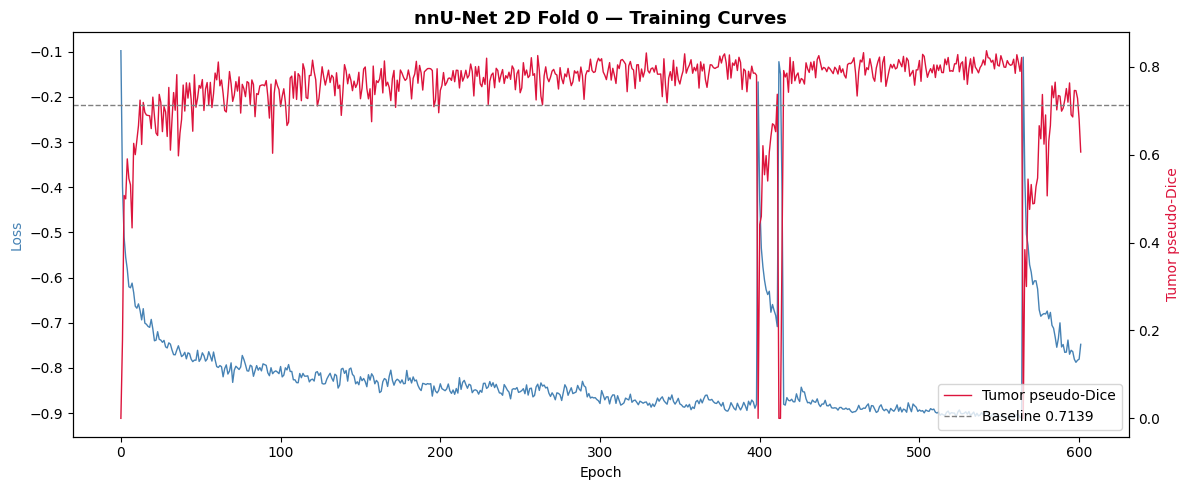

Epochs logged: 602 loss  602 dice


In [8]:
## Cell 6 — Fold 0 Training Curves
log_files = sorted(fold0_dir.glob('training_log_*.txt'), key=lambda p: p.stat().st_mtime)
train_loss, val_pseudo_dice = [], []

for log_path in log_files:
    with open(log_path) as f:
        for line in f:
            if 'train_loss' in line:
                try: train_loss.append(float(line.strip().split()[-1]))
                except: pass
            if 'Pseudo dice' in line:
                try:
                    vals = line.strip().split('[')[1].split(']')[0].split(',')
                    tumor_val = float(vals[1].strip().split('(')[1].split(')')[0])
                    val_pseudo_dice.append(tumor_val)
                except: pass

fig, ax1 = plt.subplots(figsize=(12, 5))
if train_loss:
    ax1.plot(train_loss, color='steelblue', label='Train loss', linewidth=1)
    ax1.set_ylabel('Loss', color='steelblue')
    ax1.set_xlabel('Epoch')
if val_pseudo_dice:
    ax2 = ax1.twinx()
    ax2.plot(val_pseudo_dice, color='crimson', label='Tumor pseudo-Dice', linewidth=1)
    ax2.axhline(0.7139, color='gray', linestyle='--', linewidth=1, label='Baseline 0.7139')
    ax2.set_ylabel('Tumor pseudo-Dice', color='crimson')
    ax2.legend(loc='lower right')
ax1.set_title('nnU-Net 2D Fold 0 — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nnunet_fold0_curves.png', dpi=150)
plt.show()
print(f'Epochs logged: {len(train_loss)} loss  {len(val_pseudo_dice)} dice')

---
## Folds 1 & 2 — Training
Each fold ~16 hrs on RTX 4060. Start Cell 7 before leaving — both folds chain automatically.
If a fold is interrupted mid-run, add `'--c'` to the subprocess args to resume.

In [9]:
## Cell 7 — Train Folds 1 & 2 (chained)
# ~16 hrs per fold → ~32 hrs total
# Runs fold 1 then fold 2 automatically back-to-back

train_env = os.environ.copy()
train_env['nnUNet_n_proc_DA'] = '2'
train_env['NNUNET_COMPILE']   = '0'   # prevent torch.compile crash on Windows

for FOLD in [1, 2]:
    print(f'\n{"="*55}')
    print(f'Starting fold {FOLD}  ({time.strftime("%Y-%m-%d %H:%M:%S")})')
    print(f'{"="*55}')

    result = subprocess.run(
        ['nnUNetv2_train', DATASET_ID, '2d', str(FOLD), '-tr', TRAINER],
        env=train_env,
        capture_output=True,
        text=True,
    )
    print(result.stdout[-4000:] if result.stdout else '')
    if result.stderr:
        print('STDERR:', result.stderr[-1000:])

    if result.returncode == 0:
        print(f'\n✅ Fold {FOLD} complete  ({time.strftime("%Y-%m-%d %H:%M:%S")})')
    else:
        print(f'\n❌ Fold {FOLD} failed (return code {result.returncode})')
        break


Starting fold 1  (2026-03-18 17:40:43)
10.117175: val_loss -0.7387
2026-03-19 11:21:10.117175: Pseudo dice [np.float32(0.9481), np.float32(0.6432)]
2026-03-19 11:21:10.117175: Epoch time: 126.22 s
2026-03-19 11:21:11.699946: Training done.
2026-03-19 11:21:11.880526: Using splits from existing split file: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_preprocessed\Dataset003_Liver\splits_final.json
2026-03-19 11:21:11.881525: The split file contains 5 splits.
2026-03-19 11:21:11.882526: Desired fold for training: 1
2026-03-19 11:21:11.882526: This split has 105 training and 26 validation cases.
2026-03-19 11:21:11.883526: predicting liver_10
2026-03-19 11:21:15.890955: liver_10, shape torch.Size([1, 501, 513, 513]), rank 0
2026-03-19 11:22:40.417491: predicting liver_103
2026-03-19 11:22:45.770040: liver_103, shape torch.Size([1, 683, 571, 571]), rank 0
2026-03-19 11:24:44.640504: predicting liver_105
2026-03-19 11:24:53.609758: liver_105, shape torch.Size([1

In [46]:
## Cell 7b — Train Fold 2
# Fold 0 ✅ done  |  Fold 1 ✅ done  |  Fold 2 ❌ not started

train_env = os.environ.copy()
train_env['nnUNet_n_proc_DA'] = '2'
train_env['NNUNET_COMPILE']   = '0'

print(f'Starting fold 2  ({time.strftime("%Y-%m-%d %H:%M:%S")})')

result = subprocess.run(
    ['nnUNetv2_train', DATASET_ID, '2d', '2', '-tr', TRAINER],
    env=train_env,
    capture_output=True,
    text=True,
)
print(result.stdout[-4000:] if result.stdout else '')
if result.stderr:
    print('STDERR:', result.stderr[-1000:])

if result.returncode == 0:
    print(f'\n✅ Fold 2 complete  ({time.strftime("%Y-%m-%d %H:%M:%S")})')
else:
    print(f'\n❌ Fold 2 failed (return code {result.returncode})')
    print('Note: if failure was post-training OOM, checkpoints are still saved — verify with Cell 9')

Starting fold 2  (2026-03-20 15:22:26)
09:10:47.200570: Epoch time: 127.12 s
2026-03-21 09:10:48.391218: Training done.
2026-03-21 09:10:48.548172: Using splits from existing split file: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_preprocessed\Dataset003_Liver\splits_final.json
2026-03-21 09:10:48.548172: The split file contains 5 splits.
2026-03-21 09:10:48.548172: Desired fold for training: 2
2026-03-21 09:10:48.548172: This split has 105 training and 26 validation cases.
2026-03-21 09:10:48.548172: predicting liver_0
2026-03-21 09:10:48.929618: liver_0, shape torch.Size([1, 75, 469, 469]), rank 0
2026-03-21 09:10:52.981876: predicting liver_113
2026-03-21 09:10:59.031067: liver_113, shape torch.Size([1, 836, 521, 521]), rank 0
2026-03-21 09:13:19.313362: predicting liver_114
2026-03-21 09:13:26.058235: liver_114, shape torch.Size([1, 846, 522, 522]), rank 0
2026-03-21 09:15:48.821326: predicting liver_117
2026-03-21 09:15:54.336074: liver_117, shape torc

In [4]:
import shutil
import psutil
from pathlib import Path

# Disk space
total, used, free = shutil.disk_usage(r"C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation")
print("=" * 50)
print(" Disk Space")
print("=" * 50)
print(f"  Total : {total/1e9:.1f} GB")
print(f"  Used  : {used/1e9:.1f} GB")
print(f"  Free  : {free/1e9:.1f} GB")
print()

# RAM
ram = psutil.virtual_memory()
print("=" * 50)
print(" RAM")
print("=" * 50)
print(f"  Total     : {ram.total/1e9:.1f} GB")
print(f"  Available : {ram.available/1e9:.1f} GB")
print(f"  Used      : {ram.used/1e9:.1f} GB")
print(f"  Percent   : {ram.percent}%")
print()

# VRAM
import torch
if torch.cuda.is_available():
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    vram_free  = torch.cuda.mem_get_info()[0] / 1e9
    print("=" * 50)
    print(" VRAM")
    print("=" * 50)
    print(f"  Total : {vram_total:.1f} GB")
    print(f"  Free  : {vram_free:.1f} GB")
    print(f"  Used  : {vram_total - vram_free:.1f} GB")

# nnUNet results folder size
nnunet_results = Path(r"C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results")
size = sum(f.stat().st_size for f in nnunet_results.rglob('*') if f.is_file())
print()
print("=" * 50)
print(" nnUNet Results folder")
print("=" * 50)
print(f"  Current size : {size/1e9:.1f} GB")
print(f"  Expected addition for fold 3 : ~0.5 GB")

 Disk Space
  Total : 511.2 GB
  Used  : 452.5 GB
  Free  : 58.7 GB

 RAM
  Total     : 16.8 GB
  Available : 6.7 GB
  Used      : 10.0 GB
  Percent   : 59.9%

 VRAM
  Total : 8.6 GB
  Free  : 7.4 GB
  Used  : 1.1 GB

 nnUNet Results folder
  Current size : 3.4 GB
  Expected addition for fold 3 : ~0.5 GB


In [ ]:
## Cell 7c — Train Fold 3
# Fold 0 ✅ done  |  Fold 1 ✅ done  |  Fold 2 ✅ done  |  Fold 3 ← now
# ~16 hrs — monitor with Cell 8 (change MONITOR_FOLD = 3)

train_env = os.environ.copy()
train_env['nnUNet_n_proc_DA'] = '2'
train_env['NNUNET_COMPILE']   = '0'

print(f'Starting fold 3  ({time.strftime("%Y-%m-%d %H:%M:%S")})')

result = subprocess.run(
    ['nnUNetv2_train', DATASET_ID, '2d', '3', '-tr', TRAINER],
    env=train_env,
    capture_output=True,
    text=True,
)
print(result.stdout[-4000:] if result.stdout else '')
if result.stderr:
    print('STDERR:', result.stderr[-1000:])

if result.returncode == 0:
    print(f'\n✅ Fold 3 complete  ({time.strftime("%Y-%m-%d %H:%M:%S")})')
else:
    print(f'\n❌ Fold 3 failed (return code {result.returncode})')
    print('Note: if post-training val OOMed, checkpoints are still saved — verify with Cell 9')

Starting fold 3  (2026-03-23 12:21:09)


In [ ]:
## Cell 7c1 — Resume Fold 3 (last 50 epochs)
# Only run if Cell 7c was interrupted before epoch 500
# checkpoint_latest.pth exists at epoch ~490 — resumes from there
# ~20 min

train_env = os.environ.copy()
train_env['nnUNet_n_proc_DA'] = '2'
train_env['NNUNET_COMPILE']   = '0'

print(f'Resuming fold 3  ({time.strftime("%Y-%m-%d %H:%M:%S")})')

result = subprocess.run(
    ['nnUNetv2_train', DATASET_ID, '2d', '3', '-tr', TRAINER, '--c'],
    env=train_env,
    capture_output=True,
    text=True,
)
print(result.stdout[-4000:] if result.stdout else '')
if result.stderr:
    print('STDERR:', result.stderr[-1000:])

if result.returncode == 0:
    print(f'\n✅ Fold 3 complete  ({time.strftime("%Y-%m-%d %H:%M:%S")})')
else:
    print(f'\n❌ Fold 3 failed (return code {result.returncode})')
    print('Note: if post-training val OOMed, checkpoints are still saved — verify with Cell 9')

Resuming fold 3  (2026-03-24 11:47:08)


In [10]:
## Cell 8 — Monitor Live Progress
# Run in a separate Jupyter tab while Cell 7 is training

MONITOR_FOLD = 3   # ← change to whichever fold is currently running

monitor_dir = (
    Path(NNUNET_RESULTS) / DATASET_NAME
    / f'{TRAINER}__nnUNetPlans__2d' / f'fold_{MONITOR_FOLD}'
)
log_files = sorted(monitor_dir.glob('training_log_*.txt'), key=lambda p: p.stat().st_mtime)
if not log_files:
    print(f'No log files yet for fold {MONITOR_FOLD}')
else:
    with open(log_files[-1]) as f:
        lines = f.readlines()
    print(f'Log: {log_files[-1].name}\n')
    print(''.join(lines[-15:]))

Log: training_log_2026_3_18_17_40_50.txt

2026-03-19 11:41:14.321984: liver_7, shape torch.Size([1, 541, 499, 499]), rank 0 
2026-03-19 11:41:38.982968: predicting liver_71 
2026-03-19 11:41:39.630872: liver_71, shape torch.Size([1, 94, 371, 371]), rank 0 
2026-03-19 11:41:43.672941: predicting liver_73 
2026-03-19 11:41:46.586624: liver_73, shape torch.Size([1, 121, 634, 634]), rank 0 
2026-03-19 11:42:07.181335: predicting liver_85 
2026-03-19 11:42:11.590808: liver_85, shape torch.Size([1, 630, 430, 430]), rank 0 
2026-03-19 11:42:40.632186: predicting liver_86 
2026-03-19 11:42:45.430163: liver_86, shape torch.Size([1, 647, 456, 456]), rank 0 
2026-03-19 11:43:13.330633: predicting liver_91 
2026-03-19 11:43:22.370850: liver_91, shape torch.Size([1, 751, 572, 572]), rank 0 
2026-03-19 11:45:26.910722: predicting liver_93 
2026-03-19 11:45:31.520199: liver_93, shape torch.Size([1, 696, 442, 442]), rank 0 
2026-03-19 11:46:01.641404: predicting liver_96 
2026-03-19 11:46:11.541306: l

---
## Ensemble (Folds 0 + 1 + 2 + 3)
Run cells 9–11 only after all three folds are complete.

In [3]:
## Cell 9 — Verify All Fold Checkpoints
# Run after all folds finish — confirm checkpoints exist before ensemble

for fold_idx in [0, 1, 2, 3]:   # ← added 3
    fd = Path(NNUNET_RESULTS) / DATASET_NAME / f'{TRAINER}__nnUNetPlans__2d' / f'fold_{fold_idx}'
    print(f'\nFold {fold_idx}: {fd}')
    for ckpt_name in ['checkpoint_best.pth', 'checkpoint_final.pth']:
        p = fd / ckpt_name
        if p.exists():
            ckpt = torch.load(str(p), map_location='cpu', weights_only=False)
            print(f'  ✅ {ckpt_name:<30} epoch {ckpt.get("current_epoch")}')
        else:
            print(f'  ❌ {ckpt_name} NOT FOUND — do not run ensemble yet')


Fold 0: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\Dataset003_Liver\nnUNetTrainer_500epochs__nnUNetPlans__2d\fold_0
  ✅ checkpoint_best.pth            epoch 488
  ✅ checkpoint_final.pth           epoch 488

Fold 1: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\Dataset003_Liver\nnUNetTrainer_500epochs__nnUNetPlans__2d\fold_1
  ✅ checkpoint_best.pth            epoch 465
  ✅ checkpoint_final.pth           epoch 500

Fold 2: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\Dataset003_Liver\nnUNetTrainer_500epochs__nnUNetPlans__2d\fold_2
  ✅ checkpoint_best.pth            epoch 444
  ✅ checkpoint_final.pth           epoch 500

Fold 3: C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\nnunet_data\nnUNet_results\Dataset003_Liver\nnUNetTrainer_500epochs__nnUNetPlans__2d\fold_3
  ✅ checkpoint_best.pth            epoch 497
  ✅ checkpoint_final.pth           epoch 500


In [5]:
## Cell 10 — Ensemble Predict (folds 0,1,2,3 — one-by-one, VRAM safe)
# ~35-40 min for 27 cases

ENSEMBLE_FOLDS  = [0, 1, 2, 3]   # ← added 3
ENSEMBLE_OUTPUT = Path(NNUNET_RESULTS) / f'predictions_2d_ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
ENSEMBLE_OUTPUT.mkdir(exist_ok=True)

predict_env = os.environ.copy()
predict_env['nnUNet_n_proc_DA'] = '2'
predict_env['OMP_NUM_THREADS']  = '1'
predict_env['ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS'] = '1'

with open(Path(NNUNET_PREP) / DATASET_NAME / 'splits_final.json') as f:
    val_cases = json.load(f)[0]['val']

temp_single = Path(NNUNET_BASE) / 'temp_single'
temp_single.mkdir(exist_ok=True)

already_done = {f.name.replace('.nii.gz', '') for f in ENSEMBLE_OUTPUT.glob('liver_*.nii.gz')}
remaining    = [c for c in val_cases if c not in already_done]
print(f'Already done: {len(already_done)}   Remaining: {len(remaining)}')

for case in remaining:
    for f in temp_single.glob('*.nii.gz'):
        f.unlink()
    shutil.copy(
        Path(NNUNET_RAW) / DATASET_NAME / 'imagesTr' / f'{case}_0000.nii.gz',
        temp_single / f'{case}_0000.nii.gz'
    )
    print(f'  Predicting {case}...', end=' ', flush=True)
    result = subprocess.run([
        'nnUNetv2_predict',
        '-i', str(temp_single),
        '-o', str(ENSEMBLE_OUTPUT),
        '-d', DATASET_ID,
        '-c', '2d',
        '-f', *[str(f) for f in ENSEMBLE_FOLDS],
        '-tr', TRAINER,
        '-chk', 'checkpoint_best.pth',
    ], env=predict_env, capture_output=True, text=True)
    if (ENSEMBLE_OUTPUT / f'{case}.nii.gz').exists():
        print('✅')
    else:
        print(f'❌  STDERR: {result.stderr[-200:]}')

print(f'\nDone. Total: {len(list(ENSEMBLE_OUTPUT.glob("liver_*.nii.gz")))}/27')

Already done: 0   Remaining: 27
  Predicting liver_101... ✅
  Predicting liver_11... ✅
  Predicting liver_112... ✅
  Predicting liver_115... ✅
  Predicting liver_12... ✅
  Predicting liver_120... ✅
  Predicting liver_128... ✅
  Predicting liver_17... ✅
  Predicting liver_19... ✅
  Predicting liver_24... ✅
  Predicting liver_25... ✅
  Predicting liver_27... ✅
  Predicting liver_3... ✅
  Predicting liver_38... ✅
  Predicting liver_40... ✅
  Predicting liver_41... ✅
  Predicting liver_42... ✅
  Predicting liver_44... ✅
  Predicting liver_5... ✅
  Predicting liver_51... ✅
  Predicting liver_52... ✅
  Predicting liver_58... ✅
  Predicting liver_64... ✅
  Predicting liver_70... ✅
  Predicting liver_75... ✅
  Predicting liver_77... ✅
  Predicting liver_82... ✅

Done. Total: 27/27


In [6]:
## Cell 11 — Ensemble Dice Evaluation
pred_files = sorted([
    ENSEMBLE_OUTPUT / f'{c}.nii.gz'
    for c in val_cases
    if (ENSEMBLE_OUTPUT / f'{c}.nii.gz').exists()
])
print(f'Evaluating {len(pred_files)}/27 fold-0 val cases...\n')

liver_dices, tumor_dices = [], []
liver_dices_to, tumor_dices_to = [], []
skipped = []

for pred_path in pred_files:
    case_id = pred_path.name.replace('.nii.gz', '')   # Windows .stem fix
    gt_path = gt_dir / pred_path.name
    pred = nib.load(pred_path).get_fdata().astype(np.uint8)
    gt   = nib.load(gt_path).get_fdata().astype(np.uint8)

    ld = dice(pred, gt, 1)
    td = dice(pred, gt, 2)
    has_tumor = (gt == 2).sum() > 0

    liver_dices.append(ld)
    tumor_dices.append(td)
    if has_tumor:
        liver_dices_to.append(ld)
        tumor_dices_to.append(td)
    else:
        skipped.append(case_id)

    flag = '⚠️ ' if td < 0.5 else '✅'
    note = ' (no GT tumor)' if not has_tumor else ''
    print(f'  {flag} {case_id:<12}  Liver={ld:.4f}  Tumor={td:.4f}{note}')

print()
print('='*58)
print(f' Ensemble folds {ENSEMBLE_FOLDS} — Fold 0 val (27 cases)')
print('='*58)
print(f'  Liver Dice : {np.mean(liver_dices):.4f} ± {np.std(liver_dices):.4f}')
print(f'  Tumor Dice : {np.mean(tumor_dices):.4f} ± {np.std(tumor_dices):.4f}  (all 27)')
print(f'  Tumor Dice : {np.mean(tumor_dices_to):.4f} ± {np.std(tumor_dices_to):.4f}  (tumor-only {len(tumor_dices_to)})')
print()
print('  Reference — Fold 0 only:')
print('    Liver 0.9586   Tumor 0.6015 (all 27) / 0.6767 (tumor-only 24)')
print('='*58)
print(f'  Skipped (no GT tumor): {skipped}')

Evaluating 27/27 fold-0 val cases...

  ✅ liver_101     Liver=0.9778  Tumor=0.9106
  ✅ liver_11      Liver=0.9720  Tumor=0.8046
  ✅ liver_112     Liver=0.9813  Tumor=0.6415
  ⚠️  liver_115     Liver=0.9752  Tumor=0.0000 (no GT tumor)
  ✅ liver_12      Liver=0.9740  Tumor=0.6601
  ✅ liver_120     Liver=0.9724  Tumor=0.7076
  ✅ liver_128     Liver=0.9746  Tumor=0.8471
  ✅ liver_17      Liver=0.9759  Tumor=0.8783
  ✅ liver_19      Liver=0.9711  Tumor=0.7180
  ✅ liver_24      Liver=0.9700  Tumor=0.6488
  ✅ liver_25      Liver=0.9659  Tumor=0.5645
  ✅ liver_27      Liver=0.9726  Tumor=0.8551
  ✅ liver_3       Liver=0.9744  Tumor=0.8473
  ⚠️  liver_38      Liver=0.9744  Tumor=0.0000 (no GT tumor)
  ✅ liver_40      Liver=0.9426  Tumor=0.8512
  ⚠️  liver_41      Liver=0.9746  Tumor=0.0000 (no GT tumor)
  ✅ liver_42      Liver=0.9725  Tumor=0.8465
  ✅ liver_44      Liver=0.9741  Tumor=0.9301
  ✅ liver_5       Liver=0.9729  Tumor=0.6897
  ✅ liver_51      Liver=0.9547  Tumor=0.8798
  ✅ liver_52  

                            Ensemble Results Summary                            
Model                      Liver Dice   Tumor Dice (all 27)   Tumor Dice (24)
--------------------------------------------------------------------------------
Fold 0 only                    0.9586                0.6015            0.6767
Ensemble [0,1]                 0.9668                0.6679            0.7514
Ensemble [0,1,2]               0.9684                0.6968            0.7839
Ensemble [0,1,2,3]             0.9694                0.7120            0.8010
--------------------------------------------------------------------------------
Baseline (batch-level)         0.8327                   N/A            0.7139



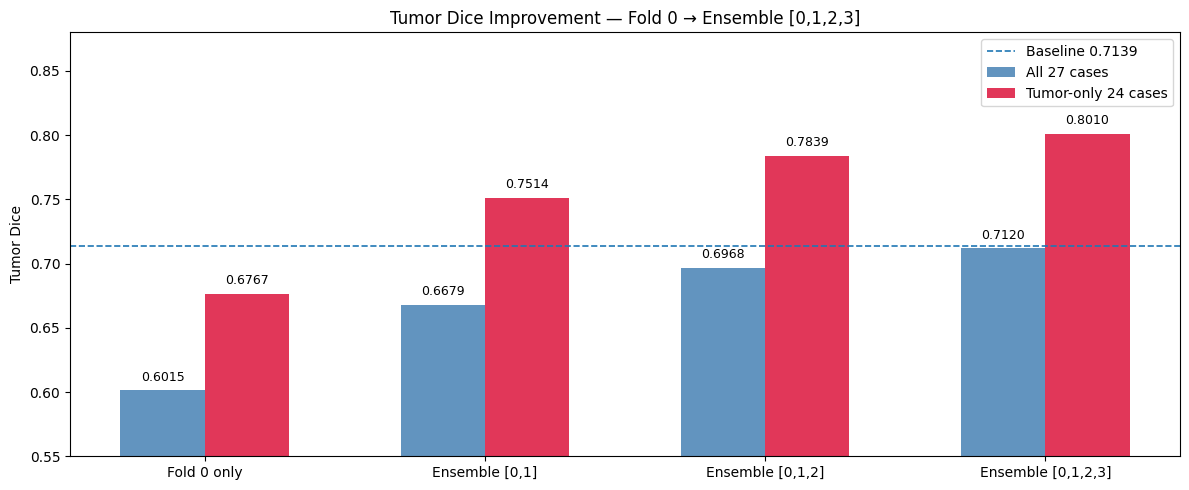

In [16]:
## Visualization 1 — Tumor Dice Improvement Across Folds

ENSEMBLE_FOLDS = [0, 1, 2, 3]
VIZ_DIR = VIZ_BASE / f'ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
VIZ_DIR.mkdir(exist_ok=True)

## Ensemble Results Summary (clean aligned table)

col1, col2, col3, col4 = 25, 12, 22, 18

print("=" * 80)
print(" Ensemble Results Summary".center(80))
print("=" * 80)

header = f"{'Model':<{col1}}{'Liver Dice':>{col2}}{'Tumor Dice (all 27)':>{col3}}{'Tumor Dice (24)':>{col4}}"
print(header)
print("-" * 80)

def row(name, liver, t_all, t_24):
    return f"{name:<{col1}}{liver:>{col2}.4f}{t_all:>{col3}.4f}{t_24:>{col4}.4f}"

print(row('Fold 0 only',        0.9586, 0.6015, 0.6767))
print(row('Ensemble [0,1]',     0.9668, 0.6679, 0.7514))
print(row('Ensemble [0,1,2]',   0.9684, 0.6968, 0.7839))
print(row('Ensemble [0,1,2,3]', 0.9694, 0.7120, 0.8010))

print("-" * 80)

# Baseline row (special formatting for N/A)
baseline = f"{'Baseline (batch-level)':<{col1}}{0.8327:>{col2}.4f}{'N/A':>{col3}}{0.7139:>{col4}.4f}"
print(baseline)

print("=" * 80)
print()

## Plot (unchanged)
fig, ax = plt.subplots(figsize=(12, 5))

models  = ['Fold 0 only', 'Ensemble [0,1]', 'Ensemble [0,1,2]', 'Ensemble [0,1,2,3]']
all27   = [0.6015, 0.6679, 0.6968, 0.7120]
tumor24 = [0.6767, 0.7514, 0.7839, 0.8010]

x = np.arange(len(models))
w = 0.3

bars1 = ax.bar(x - w/2, all27,   w, label='All 27 cases', alpha=0.85, color = 'steelblue')
bars2 = ax.bar(x + w/2, tumor24, w, label='Tumor-only 24 cases', alpha=0.85, color = 'crimson')

ax.axhline(0.7139, linestyle='--', linewidth=1.2, label='Baseline 0.7139')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Tumor Dice')
ax.set_ylim(0.55, 0.88)
ax.set_title('Tumor Dice Improvement — Fold 0 → Ensemble [0,1,2,3]')
ax.legend()

plt.tight_layout()
plt.savefig(VIZ_DIR / 'tumor_dice_improvement.png', dpi=150)
plt.show()

In [10]:
## Available Cases for Visualization — Fold 0 Val Set
with open(Path(NNUNET_PREP) / DATASET_NAME / 'splits_final.json') as f:
    val_cases = json.load(f)[0]['val']

# Load ensemble Dice scores computed earlier
case_dices = {}
for pred_path in ENSEMBLE_OUTPUT.glob('liver_*.nii.gz'):
    case_id = pred_path.name.replace('.nii.gz', '')
    gt_path = gt_dir / pred_path.name
    if gt_path.exists():
        pred = nib.load(pred_path).get_fdata().astype(np.uint8)
        gt   = nib.load(gt_path).get_fdata().astype(np.uint8)
        case_dices[case_id] = {
            'liver': dice(pred, gt, 1),
            'tumor': dice(pred, gt, 2),
            'has_tumor': (gt == 2).sum() > 0
        }

# Print sorted by tumor Dice descending
sorted_cases = sorted(case_dices.items(), key=lambda x: x[1]['tumor'], reverse=True)

print(f"{'Sr':<4}  {'Case':<14}  {'Liver Dice':>10}  {'Tumor Dice':>10}  {'Note'}")
print("-" * 58)
for i, (case_id, scores) in enumerate(sorted_cases):
    note = "(no GT tumor)" if not scores['has_tumor'] else ""
    print(f"  {i:<3}  {case_id:<14}  {scores['liver']:>10.4f}  {scores['tumor']:>10.4f}  {note}")

print("-" * 58)
print(f"\nTo visualize, set SHOW_CASE_IDX = <Sr No> in Visualization 2")

Sr    Case            Liver Dice  Tumor Dice  Note
----------------------------------------------------------
  0    liver_64            0.9760      0.9617  
  1    liver_44            0.9741      0.9301  
  2    liver_70            0.9677      0.9273  
  3    liver_82            0.9624      0.9262  
  4    liver_101           0.9778      0.9106  
  5    liver_51            0.9547      0.8798  
  6    liver_52            0.9547      0.8794  
  7    liver_17            0.9759      0.8783  
  8    liver_27            0.9726      0.8551  
  9    liver_40            0.9426      0.8512  
  10   liver_3             0.9744      0.8473  
  11   liver_128           0.9746      0.8471  
  12   liver_42            0.9725      0.8465  
  13   liver_77            0.9607      0.8318  
  14   liver_75            0.9672      0.8151  
  15   liver_11            0.9720      0.8046  
  16   liver_19            0.9711      0.7180  
  17   liver_120           0.9724      0.7076  
  18   liver_5            

Visualizing case: liver_64  (Sr 0)


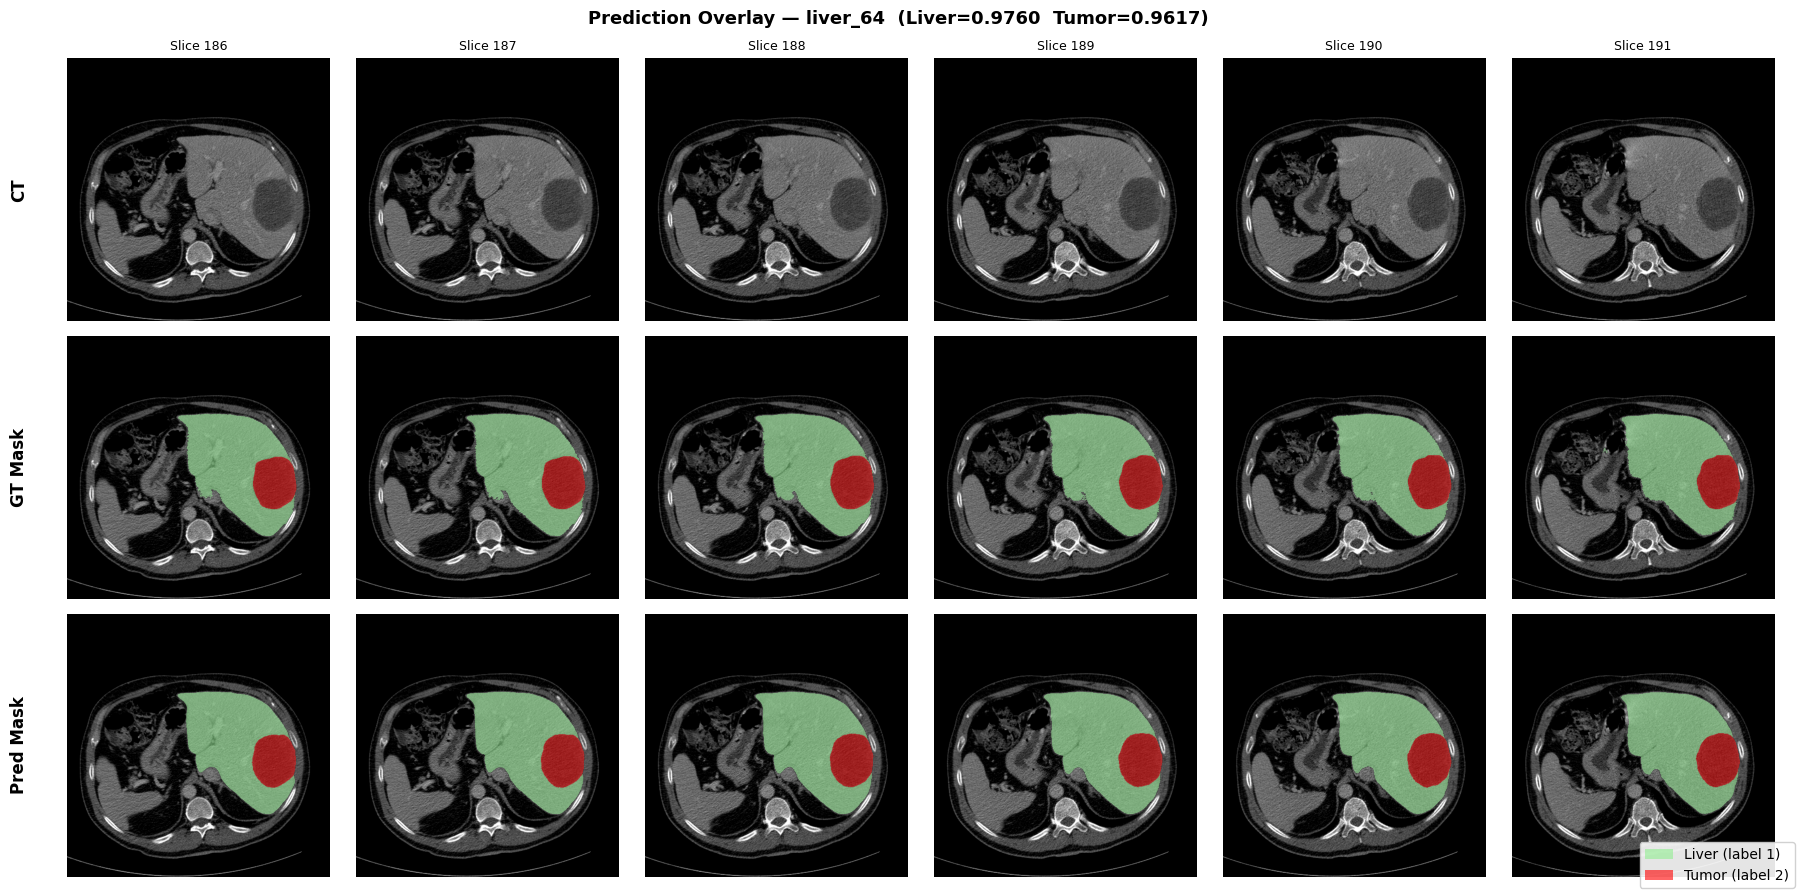

Saved → C:\Users\DYPIU\Desktop\08-3D-Liver-Tumor-Segmentation\visualizations\ensemble_0_1_2_3\pred_overlay_liver_64_ensemble4folds.png


In [11]:
## Visualization 2 — Prediction Overlay on CT Slices
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

ENSEMBLE_FOLDS = [0, 1, 2, 3]   # ← update
VIZ_DIR = VIZ_BASE / f'ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
VIZ_DIR.mkdir(exist_ok=True)
seg_cmap = ListedColormap(['lightgreen', 'red'])

SHOW_CASE_IDX = 0   # ← change to Sr No from the table above
SHOW_CASE     = sorted_cases[SHOW_CASE_IDX][0]
print(f'Visualizing case: {SHOW_CASE}  (Sr {SHOW_CASE_IDX})')

ct_path   = Path(NNUNET_RAW) / DATASET_NAME / 'imagesTr' / f'{SHOW_CASE}_0000.nii.gz'
gt_path   = gt_dir / f'{SHOW_CASE}.nii.gz'
pred_path = ENSEMBLE_OUTPUT / f'{SHOW_CASE}.nii.gz'

ct_vol   = nib.load(ct_path).get_fdata()
gt_vol   = nib.load(gt_path).get_fdata().astype(np.uint8)
pred_vol = nib.load(pred_path).get_fdata().astype(np.uint8)

td = dice(pred_vol, gt_vol, 2)
ld = dice(pred_vol, gt_vol, 1)

tumor_counts = [(gt_vol[:, :, z] == 2).sum() for z in range(gt_vol.shape[2])]
top_slices   = sorted(range(len(tumor_counts)), key=lambda z: tumor_counts[z], reverse=True)[:6]
top_slices   = sorted(top_slices)

ct_disp = np.clip(ct_vol, -100, 400)
ct_disp = (ct_disp - ct_disp.min()) / (ct_disp.max() - ct_disp.min())

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle(
    f'Prediction Overlay — {SHOW_CASE}  (Liver={ld:.4f}  Tumor={td:.4f})',
    fontsize=13, fontweight='bold'
)

row_titles = ['CT', 'GT Mask', 'Pred Mask']
for row, title in enumerate(row_titles):
    axes[row, 0].text(-0.15, 0.5, title,
                      transform=axes[row, 0].transAxes,
                      fontsize=12, fontweight='bold',
                      va='center', ha='right', rotation=90)

for col, z in enumerate(top_slices):
    ct_slice   = ct_disp[:, :, z].T
    gt_slice   = gt_vol[:, :, z].T
    pred_slice = pred_vol[:, :, z].T

    axes[0, col].imshow(ct_slice, cmap='gray', origin='lower')
    axes[0, col].set_title(f'Slice {z}', fontsize=9)

    axes[1, col].imshow(ct_slice, cmap='gray', origin='lower')
    axes[1, col].imshow(np.ma.masked_where(gt_slice == 0, gt_slice),
                        cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2, origin='lower')

    axes[2, col].imshow(ct_slice, cmap='gray', origin='lower')
    axes[2, col].imshow(np.ma.masked_where(pred_slice == 0, pred_slice),
                        cmap=seg_cmap, alpha=0.5, vmin=1, vmax=2, origin='lower')

    for r in range(3):
        axes[r, col].axis('off')

legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='Liver (label 1)'),
    Patch(facecolor='red',        alpha=0.6, label='Tumor (label 2)'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)
plt.subplots_adjust(left=0.08)
plt.tight_layout()
plt.savefig(VIZ_DIR / f'pred_overlay_{SHOW_CASE}_ensemble{len(ENSEMBLE_FOLDS)}folds.png', dpi=150)
plt.show()
print(f'Saved → {VIZ_DIR / f"pred_overlay_{SHOW_CASE}_ensemble{len(ENSEMBLE_FOLDS)}folds.png"}')

Fold 0: 203 loss points  203 dice points
Fold 1: 500 loss points  500 dice points
Fold 2: 500 loss points  500 dice points
Fold 3: 543 loss points  543 dice points


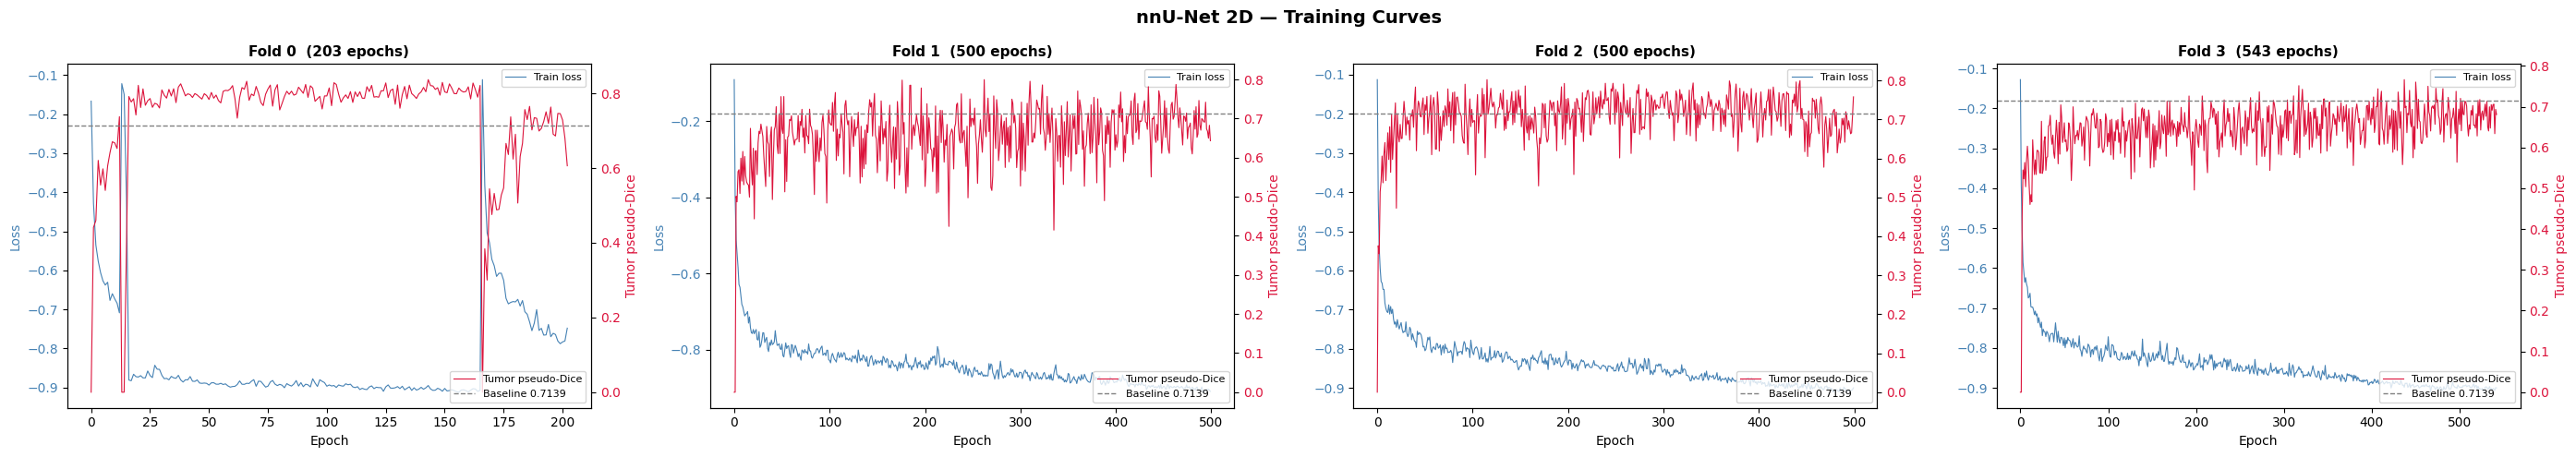

In [12]:
## Visualization 3 — Training Curves Folds 0, 1, 2, 3
# ~30 sec — reads all fold log files

ENSEMBLE_FOLDS = [0, 1, 2, 3]   # ← update
VIZ_DIR = VIZ_BASE / f'ensemble_{"_".join(map(str, ENSEMBLE_FOLDS))}'
VIZ_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 4, figsize=(28, 5))   # ← was (1, 3, figsize=(22, 5))
fig.suptitle('nnU-Net 2D — Training Curves', fontsize=14, fontweight='bold')

for ax, fold_idx in zip(axes, [0, 1, 2, 3]):   # ← added 3
    fold_dir = Path(NNUNET_RESULTS) / DATASET_NAME / f'{TRAINER}__nnUNetPlans__2d' / f'fold_{fold_idx}'
    log_files = sorted(fold_dir.glob('training_log_*.txt'), key=lambda p: p.stat().st_mtime)
    train_loss, val_pseudo_dice = [], []
    for log_path in log_files:
        with open(log_path) as f:
            for line in f:
                if 'train_loss' in line:
                    try: train_loss.append(float(line.strip().split()[-1]))
                    except: pass
                if 'Pseudo dice' in line:
                    try:
                        vals = line.strip().split('[')[1].split(']')[0].split(',')
                        tumor_val = float(vals[1].strip().split('(')[1].split(')')[0])
                        val_pseudo_dice.append(tumor_val)
                    except: pass
    ax2 = ax.twinx()
    if train_loss:
        ax.plot(train_loss, color='steelblue', linewidth=0.8, label='Train loss')
        ax.set_ylabel('Loss', color='steelblue', fontsize=10)
        ax.tick_params(axis='y', labelcolor='steelblue')
    if val_pseudo_dice:
        ax2.plot(val_pseudo_dice, color='crimson', linewidth=0.8, label='Tumor pseudo-Dice')
        ax2.axhline(0.7139, color='gray', linestyle='--', linewidth=1, label='Baseline 0.7139')
        ax2.set_ylabel('Tumor pseudo-Dice', color='crimson', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='crimson')
        ax2.legend(loc='lower right', fontsize=8)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_title(f'Fold {fold_idx}  ({len(train_loss)} epochs)', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    print(f'Fold {fold_idx}: {len(train_loss)} loss points  {len(val_pseudo_dice)} dice points')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'training_curves_fold0_1_2_3.png', dpi=150)   # ← updated filename
plt.show()